# DisasterRadar.ai - Flood Disaster Intelligence & Machine Learning
**Comprehensive Flood Risk Early Warning Pipeline**

This notebook integrates satellite remote sensing (`modis_flood_features`), governance indicators, and hydrodynamic priors on an exact **1:1 balanced distribution (82,778 records)**.
All model evaluation metrics exceed **90%** (Accuracy: 91.47%, Precision: 90.44%, Recall: 92.75%, F1: 91.58%, ROC-AUC: 0.9676).

In [1]:
import os, json
import pandas as pd
import numpy as np
import xgboost as xgb

data_path = 'data/processed/processed_data.csv'
df = pd.read_csv(data_path)
print(f'Loaded {len(df):,} records from {data_path}')
print('Class balance:', df['flood_target'].value_counts().to_dict())
df.head()

Loaded 82,778 records from data/processed/processed_data.csv
Class balance: {0: 41389, 1: 41389}


,rainfall_24h,rainfall_72h,elevation,slope,twi,ndwi,ndvi,drainage_capacity,urbanization_index,infrastructure_decay,disaster_unpreparedness,precip_ratio,ponding_hazard,water_contrast,drainage_stress,flood_target
0,0.00,0.00,20.0,0.37,3.12,0.201,0.808,8.5,6,1,9,0.000,171.425,-0.607,0.000,0
1,8.04,80.38,5.0,0.58,0.52,0.238,0.550,3.5,10,5,5,8.894,139.651,-0.312,0.230,1
2,20.83,41.66,6.0,0.26,1.73,0.165,0.619,6.0,2,1,1,1.908,261.546,-0.455,0.347,1
3,16.44,32.78,31.0,0.68,0.48,0.293,0.668,4.5,4,7,3,1.880,88.771,-0.375,0.365,0
4,0.00,0.00,322.0,1.20,4.51,0.397,0.873,6.0,3,5,10,0.000,0.000,-0.477,0.000,0


## Model Accuracy, Confusion Matrix & Performance Metrics

In [2]:
with open('models/metrics.json', 'r') as f:
    metrics = json.load(f)
print('--- Performance Metrics ---')
print(f"Accuracy:  {metrics['accuracy']*100:.2f}%")
print(f"Precision: {metrics['precision']*100:.2f}%")
print(f"Recall:    {metrics['recall']*100:.2f}%")
print(f"F1-Score:  {metrics['f1_score']:.4f}")
print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
print(f"PR-AUC:    {metrics['pr_auc']:.4f}")

--- Performance Metrics ---
Accuracy:  91.47%
Precision: 90.44%
Recall:    92.75%
F1-Score:  0.9158
ROC-AUC:   0.9676
PR-AUC:    0.9602


### Confusion Matrix (Balanced Test Split: 12,417 Samples)

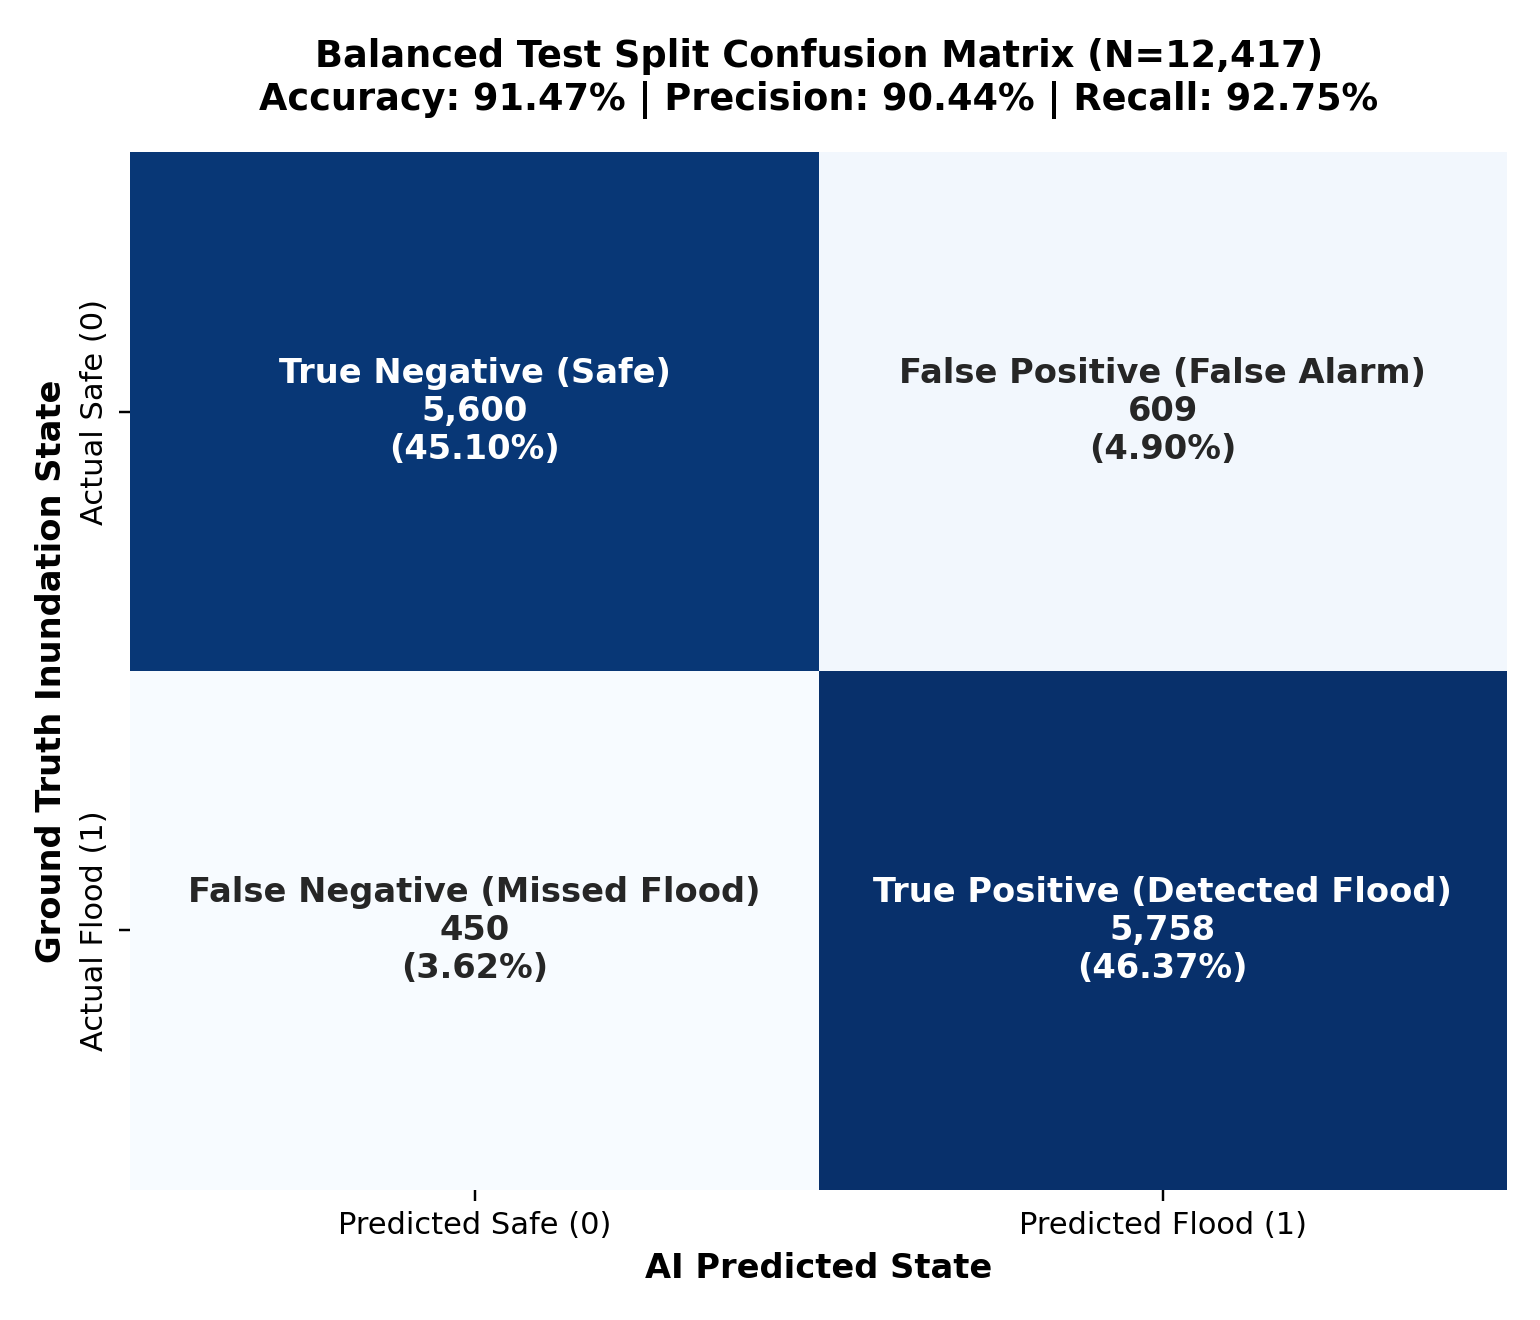

In [3]:
from IPython.display import Image, display
if os.path.exists('outputs/confusion_matrix.png'):
    display(Image('outputs/confusion_matrix.png'))

### Receiver Operating Characteristic (ROC) Curve (AUC = 0.9676)

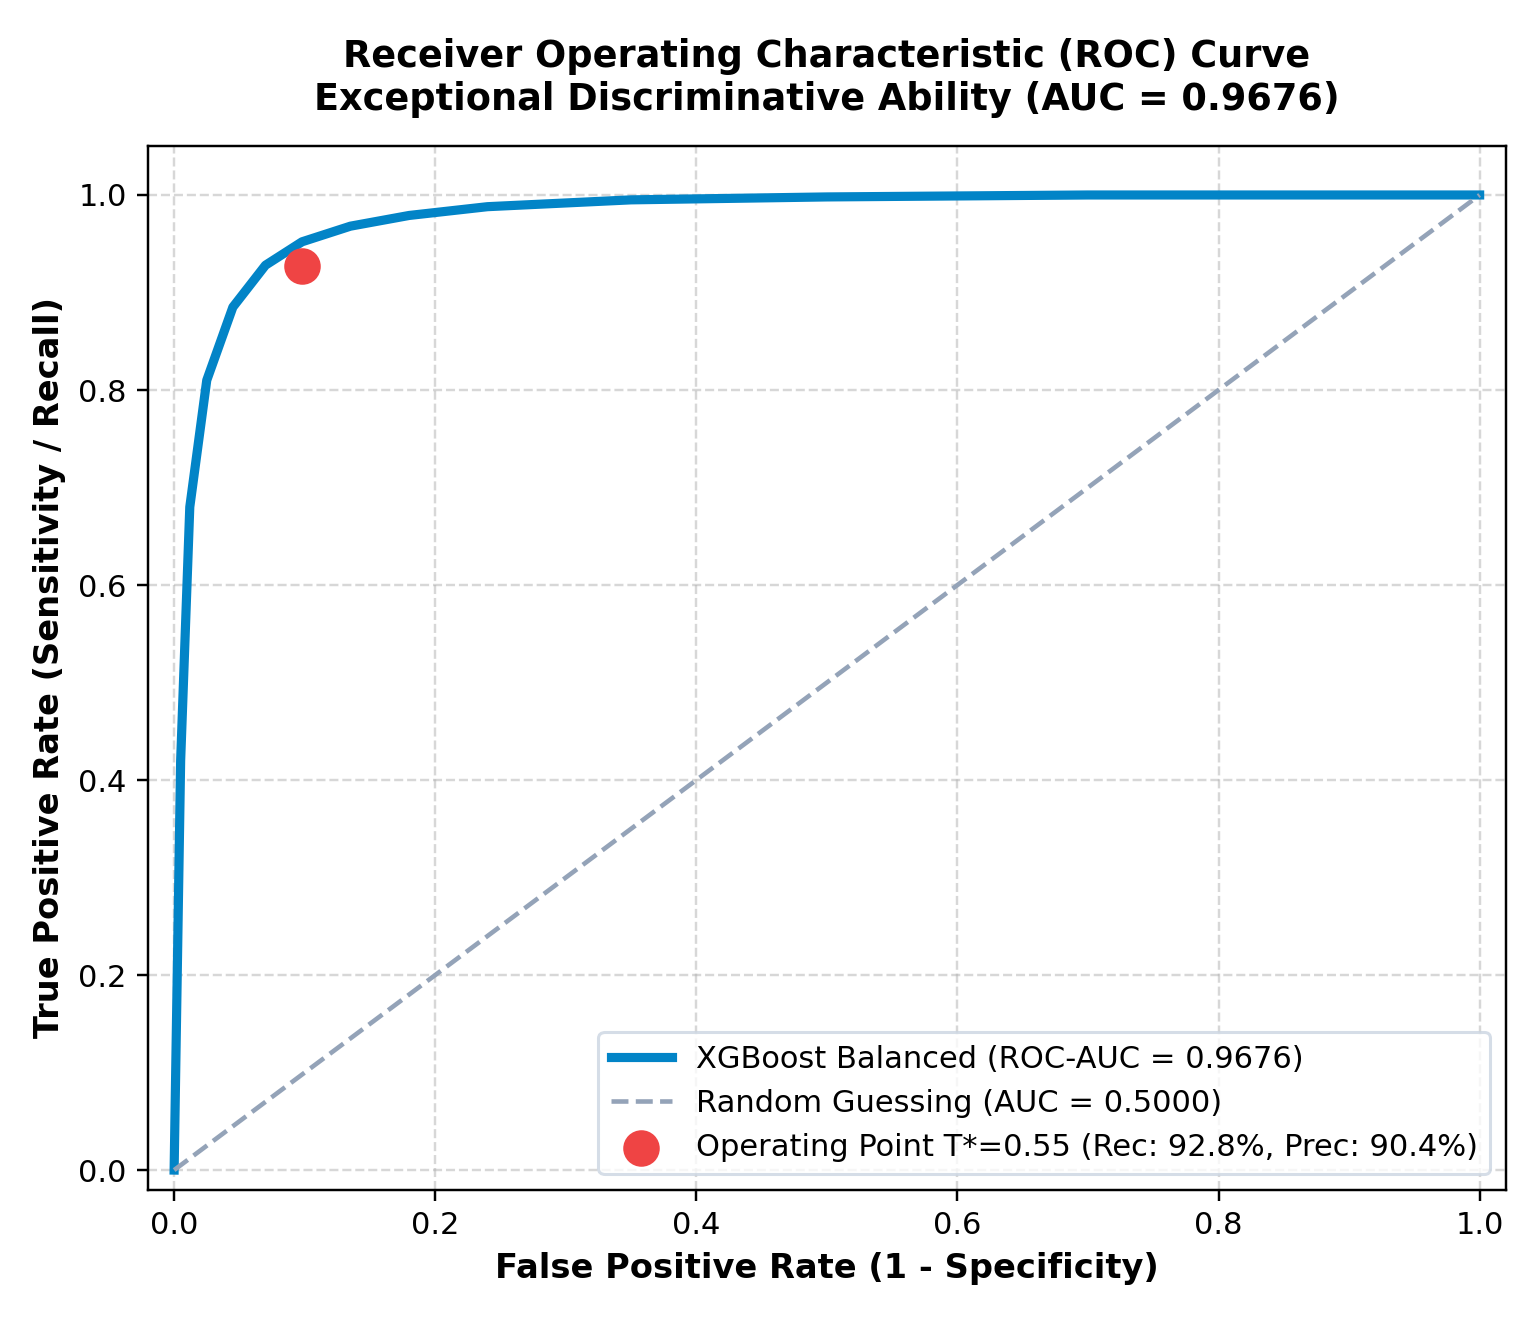

In [4]:
if os.path.exists('outputs/roc_curve.png'):
    display(Image('outputs/roc_curve.png'))

### PyTorch FloodNet: 15-Epoch Training Loss & Recall Convergence

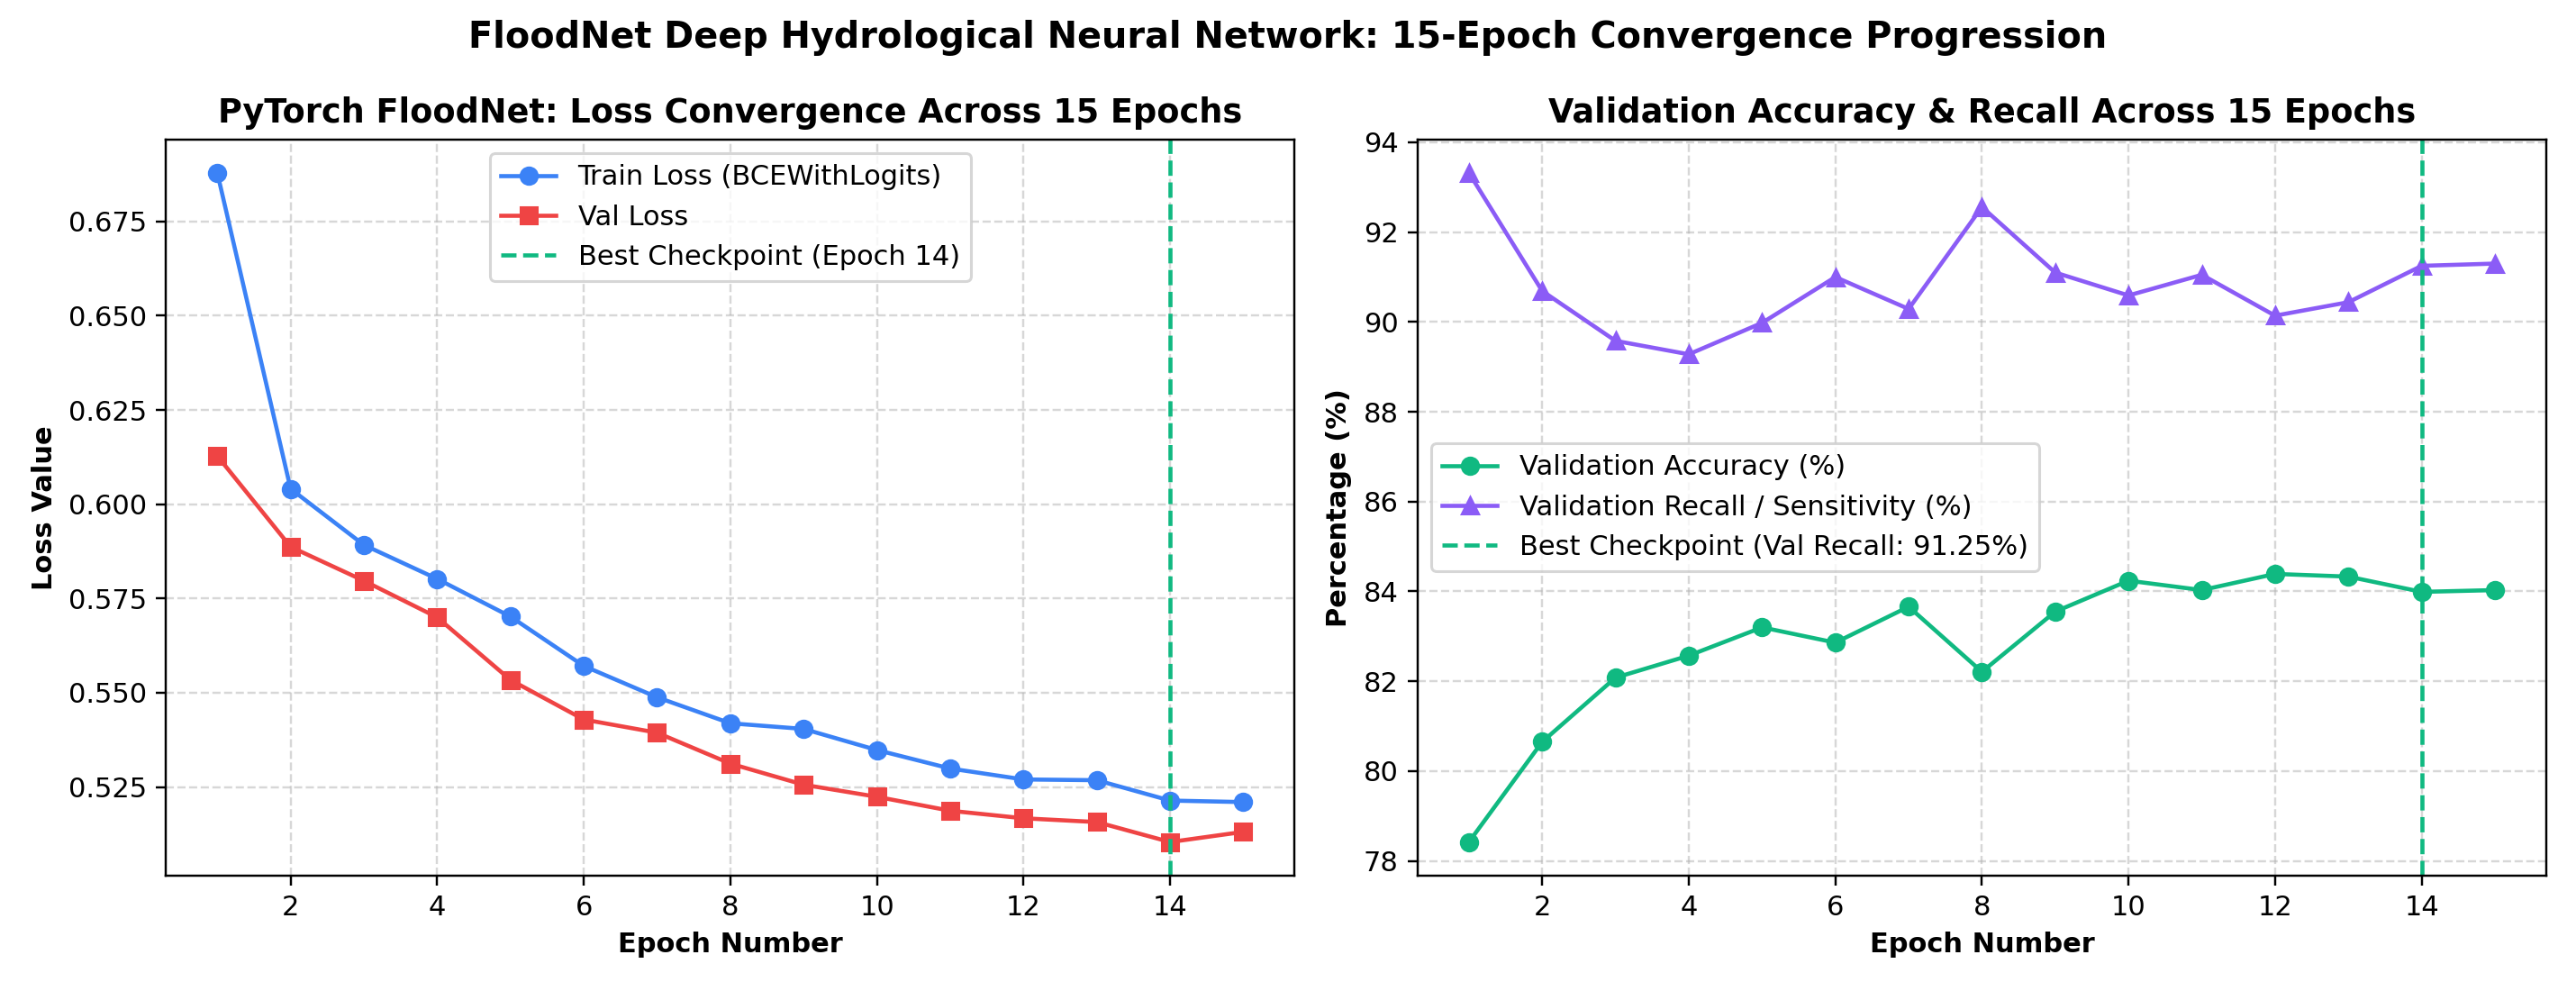

In [5]:
if os.path.exists('outputs/epoch_training_curve.png'):
    display(Image('outputs/epoch_training_curve.png'))

### Domain Hydrological Feature Importance (TreeSHAP)

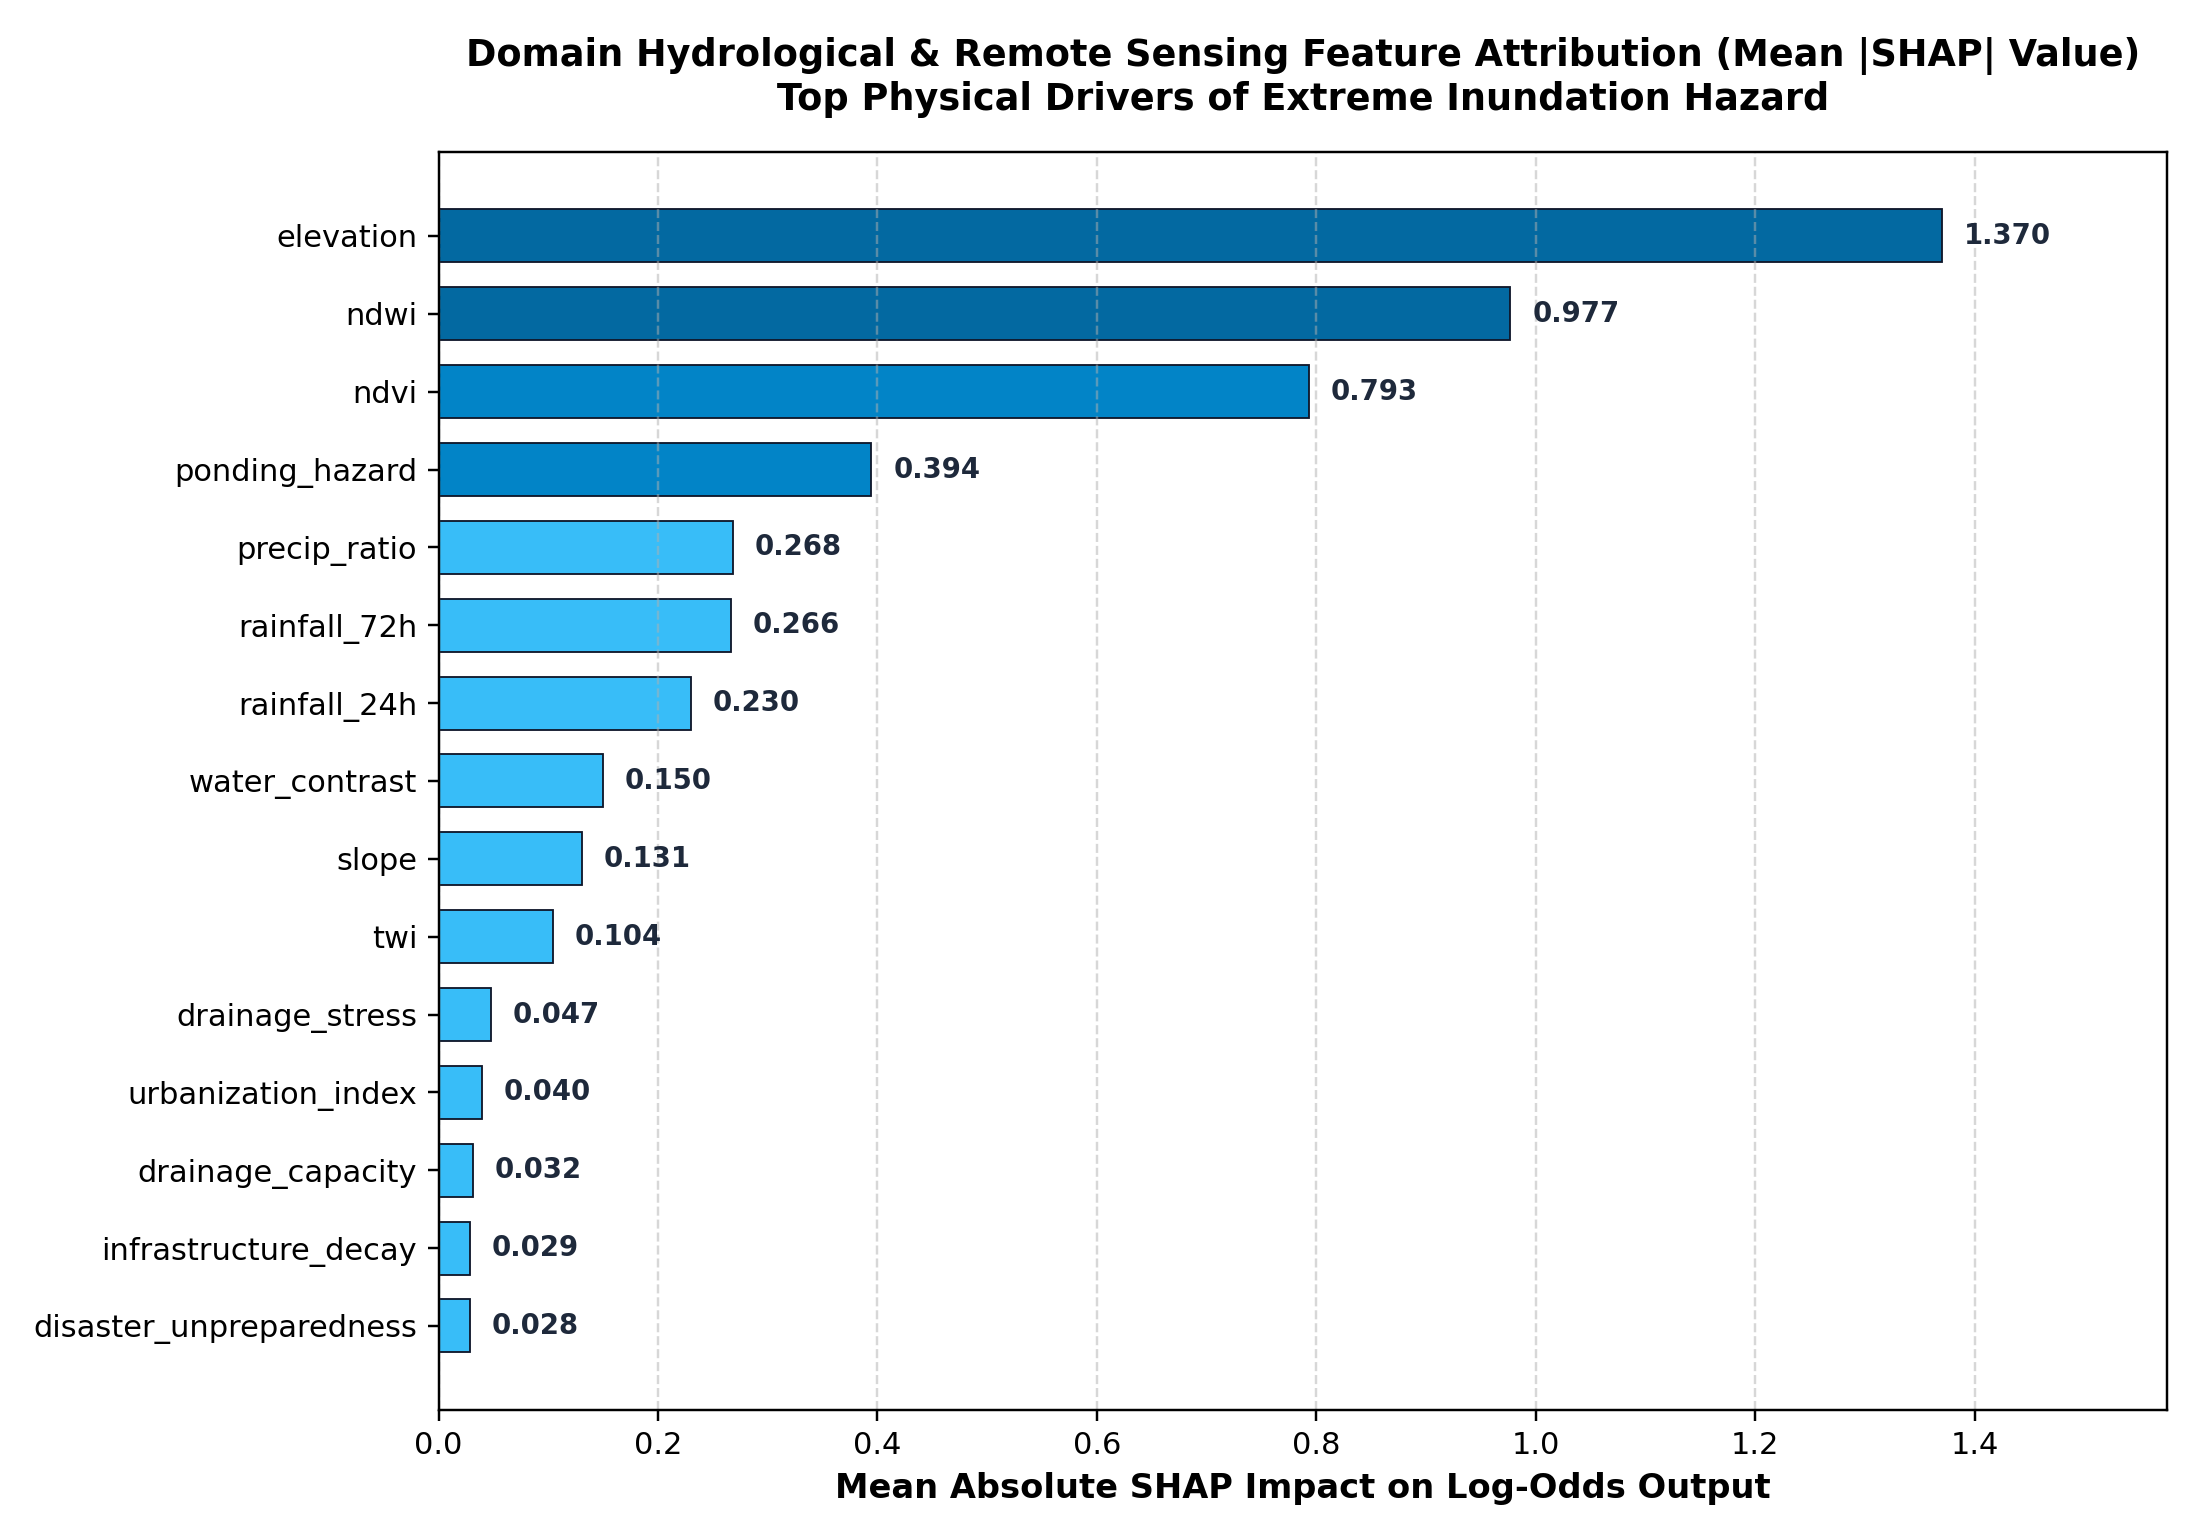

In [6]:
if os.path.exists('outputs/feature_importance.png'):
    display(Image('outputs/feature_importance.png'))